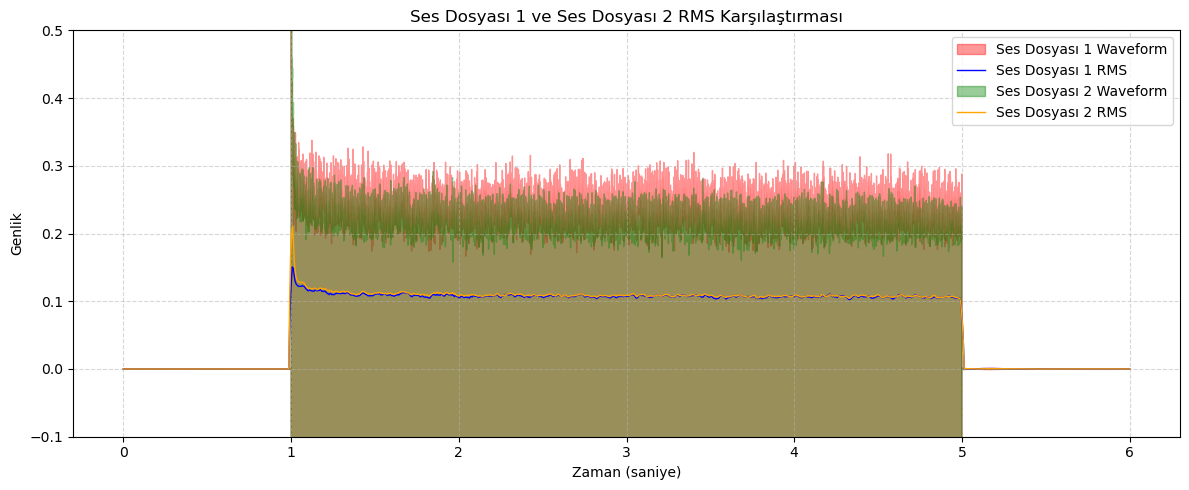

In [7]:
import matplotlib.pyplot as plt # Grafik çizimleri için kullanılan kütüphane
import numpy as np # Sayısal hesaplamalar için numpy kütüphanesi
import librosa # Ses yükleme ve analizi
import librosa.display # Ses dalga formu görselleştirme

# Ses dosyalarının yolları
file_1 = "/Users/nazimerensahin/Desktop/1.wav" # İlk karşılaştırılacak ses dosyasının yolu
file_2 = "/Users/nazimerensahin/Desktop/2.wav" # İkinci karşılaştırılacak ses dosyasının yolu

# Ses dosyalarının isimlendirmeleri
label_1 = "Ses Dosyası 1" # Grafik etiketi için ilk dosya ismi
label_2 = "Ses Dosyası 2" # Grafik etiketi için ikinci dosya ismi

# RMS (Root Mean Square) hesaplama fonksiyonu
# Bu fonksiyon RMS değerlerini ve zaman bilgilerini döner
def compute_rms(sound, sr, frame_length=2048, hop_length=512):
    rms = librosa.feature.rms(y=sound, frame_length=frame_length, hop_length=hop_length)[0] # RMS değerlerini hesaplama
    time = librosa.times_like(rms, sr=sr, hop_length=hop_length) # Zaman ekseni oluşturma
    return rms, time

# Ses dosyalarını yükle
sound_1, sr_1 = librosa.load(file_1, sr=None) # İlk ses dosyasını yükleme
sound_2, sr_2 = librosa.load(file_2, sr=None) # İkinci ses dosyasını yükleme

# RMS değerlerini hesapla
rms_1, time_1 = compute_rms(sound_1, sr_1) # İlk ses dosyası için RMS hesaplama
rms_2, time_2 = compute_rms(sound_2, sr_2) # İkinci ses dosyası için RMS hesaplama

# Grafik oluştur
plt.figure(figsize=(12, 5)) # Grafik boyutunu ayarlama

# İki sinyali ve RMS grafiklerini aynı eksende çizme
librosa.display.waveshow(sound_1, sr=sr_1, alpha=0.4, color='red', label=f"{label_1} Waveform") # Birinci ses dalgası
plt.plot(time_1, rms_1, color="blue", linewidth=1, label=f"{label_1} RMS") # Birinci RMS eğrisi

librosa.display.waveshow(sound_2, sr=sr_2, alpha=0.4, color='green', label=f"{label_2} Waveform") # İkinci ses dalgası
plt.plot(time_2, rms_2, color="orange", linewidth=1, label=f"{label_2} RMS") # İkinci RMS eğrisi

plt.title(f"{label_1} ve {label_2} RMS Karşılaştırması") # Grafik başlığı
plt.xlabel("Zaman (saniye)") # X ekseni etiketi
plt.ylabel("Genlik") # Y ekseni etiketi
plt.ylim((-0.1, 0.5)) # Y ekseni sınırları
plt.legend(fontsize=10, loc="upper right") # Etiketleri gösterme
plt.grid(True, linestyle='--', alpha=0.5) # Grafik ızgara çizgileri
plt.tight_layout() # Otomatik yerleşim düzenlemesi
plt.show() # Grafiği gösterme